<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import kagglehub
path = kagglehub.dataset_download("dileep070/heart-disease-prediction-using-logistic-regression")

100%|██████████| 58.4k/58.4k [00:00<00:00, 38.4MB/s]

Extracting files...


In [4]:
import os
import pandas as pd

# List contents of the downloaded path to find the CSV file
file_list = os.listdir(path)
print(f"Files in the downloaded directory: {file_list}")

# Corrected CSV file name based on the actual content of the directory
csv_file_name = 'framingham.csv' # Adjusted to the correct file name
full_csv_path = os.path.join(path, csv_file_name)

# Load the data into a pandas DataFrame
df = pd.read_csv(full_csv_path)

# Display the first 5 rows of the DataFrame
display(df.head())

Files in the downloaded directory: ['framingham.csv']


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


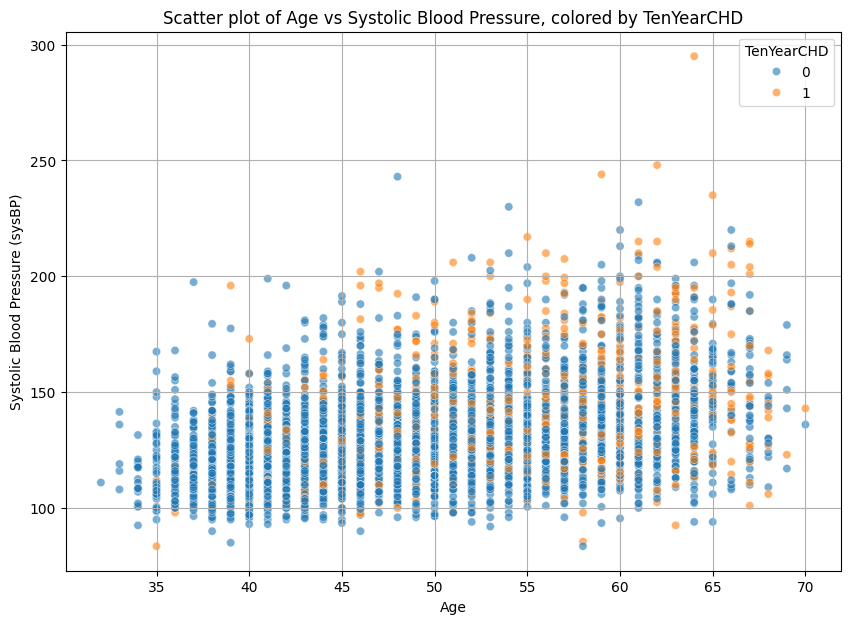

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='age', y='sysBP', hue='TenYearCHD', alpha=0.6)
plt.title('Scatter plot of Age vs Systolic Blood Pressure, colored by TenYearCHD')
plt.xlabel('Age')
plt.ylabel('Systolic Blood Pressure (sysBP)')
plt.grid(True)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


In [7]:
from sklearn.model_selection import train_test_split

# Handle missing values by dropping rows with NaNs. This is a common and simple approach
# but more sophisticated imputation methods could be used depending on the analysis requirements.
df_cleaned = df.dropna()

# Define features (X) and target (y)
# 'TenYearCHD' is assumed to be the target variable indicating a 10-year risk of coronary heart disease.
X = df_cleaned.drop('TenYearCHD', axis=1)
y = df_cleaned['TenYearCHD']

# Apply train-test split
# test_size=0.2 means 20% of data will be used for testing, 80% for training
# random_state ensures reproducibility of the split, meaning you get the same split every time you run it
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {x_train.shape}")
print(f"Shape of X_test: {x_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2924, 15)
Shape of X_test: (732, 15)
Shape of y_train: (2924,)
Shape of y_test: (732,)


In [11]:
lr=LogisticRegression

In [14]:
# Re-instantiate LogisticRegression as an object (as it was previously assigned as the class)
lr = LogisticRegression(random_state=42, solver='liblinear') # Added random_state for reproducibility and solver for stability

# Train the Logistic Regression model using the fit method
lr.fit(x_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [15]:
pre=lr.predict(x_test)

In [16]:
accuracy_score(y_test,pre)

0.8333333333333334

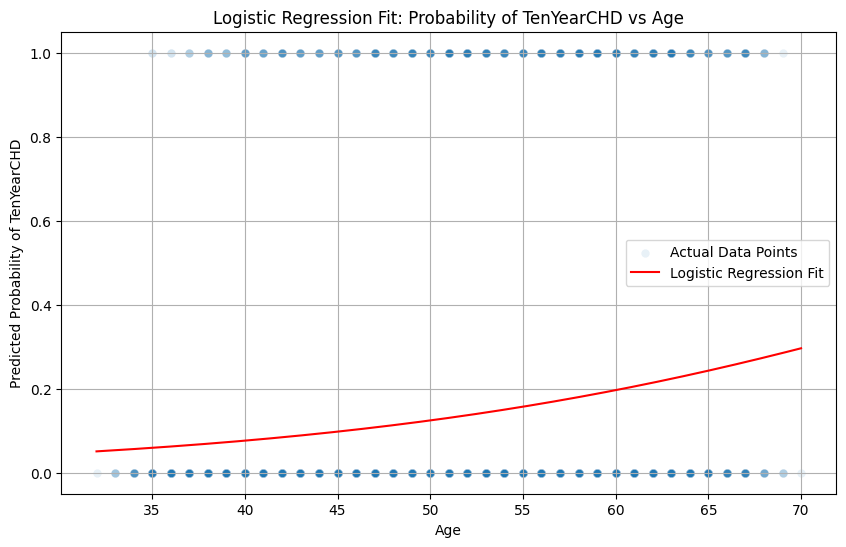

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Create a range of age values for plotting
age_range = np.linspace(X['age'].min(), X['age'].max(), 300)

# Get the mean of all features in X
mean_features = X.mean()

# Create a single-row DataFrame from the mean features
mean_df_row = pd.DataFrame([mean_features.values], columns=X.columns)

# Repeat this single row to create dummy_X with the length of age_range
dummy_X = pd.concat([mean_df_row]*len(age_range), ignore_index=True)

# Now, vary only the 'age' feature in dummy_X
dummy_X['age'] = age_range

# Predict probabilities for the dummy data
# We need the probability of the positive class (TenYearCHD=1)
probabilities = lr.predict_proba(dummy_X)[:, 1]

# Plotting the logistic fit line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['age'], y=y, alpha=0.1, label='Actual Data Points')
plt.plot(age_range, probabilities, color='red', label='Logistic Regression Fit')

plt.title('Logistic Regression Fit: Probability of TenYearCHD vs Age')
plt.xlabel('Age')
plt.ylabel('Predicted Probability of TenYearCHD')
plt.legend()
plt.grid(True)
plt.show()

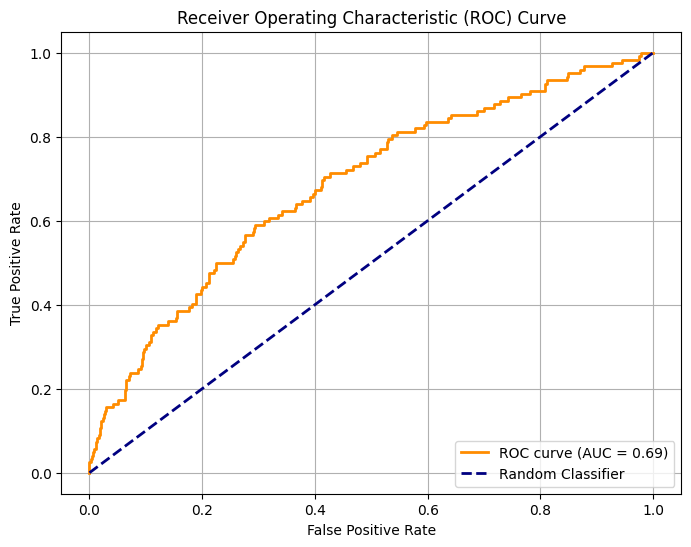

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Get predicted probabilities for the positive class (TenYearCHD=1)
y_pred_proba = lr.predict_proba(x_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate Area Under the Curve (AUC)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The ROC curve helps evaluate the model's ability to discriminate between classes. A higher AUC (Area Under the Curve) generally indicates a better performing model. Now, let's look at the Confusion Matrix to see the types of correct and incorrect predictions.

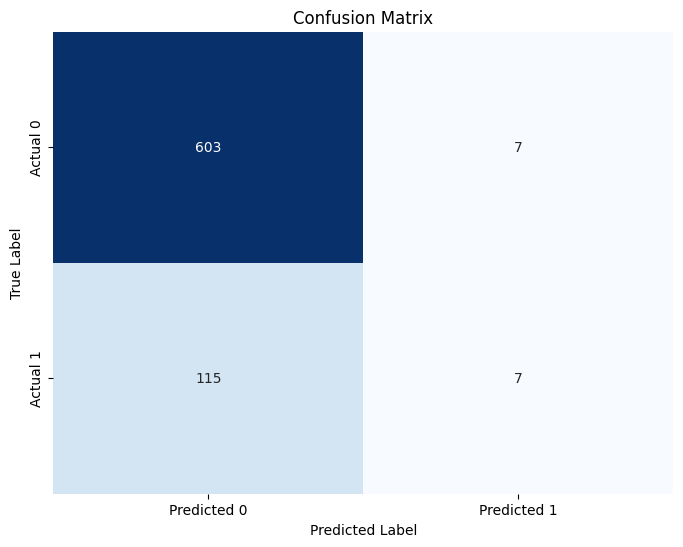

In [21]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, pre)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()